In [569]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display
import joblib

from sklearn.impute import SimpleImputer 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, Normalizer, MaxAbsScaler, RobustScaler, PowerTransformer, PolynomialFeatures

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, cross_val_predict, GridSearchCV, KFold, ShuffleSplit, StratifiedShuffleSplit, StratifiedKFold, StratifiedGroupKFold, GroupKFold, GroupShuffleSplit, RepeatedKFold, RepeatedStratifiedKFold 
from sklearn.metrics import accuracy_score, precision_score, recall_score, make_scorer, PrecisionRecallDisplay, precision_recall_curve, RocCurveDisplay, roc_curve, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

# regression
from sklearn.metrics import mean_squared_error as mse, root_mean_squared_error as rmse, mean_absolute_error as mae, r2_score as r2s, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, VotingClassifier, StackingRegressor, StackingClassifier
from sklearn.svm import LinearSVC

In [570]:
!pip install imblearn

In [571]:
df = pd.read_csv('/Users/nidakhan/Downloads/HR_comma_sep.csv')
df[:5]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [572]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='str')

In [573]:
df.columns = df.columns.str.lower()

In [574]:
df.rename(columns = {'sales': 'department'}, inplace = True)
df[:5]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [575]:
df.shape

(14999, 10)

In [576]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [577]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [578]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [579]:
corr_matrix = df.corr(numeric_only = True)

In [580]:
corr_matrix['left'].sort_values(ascending = False)

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64

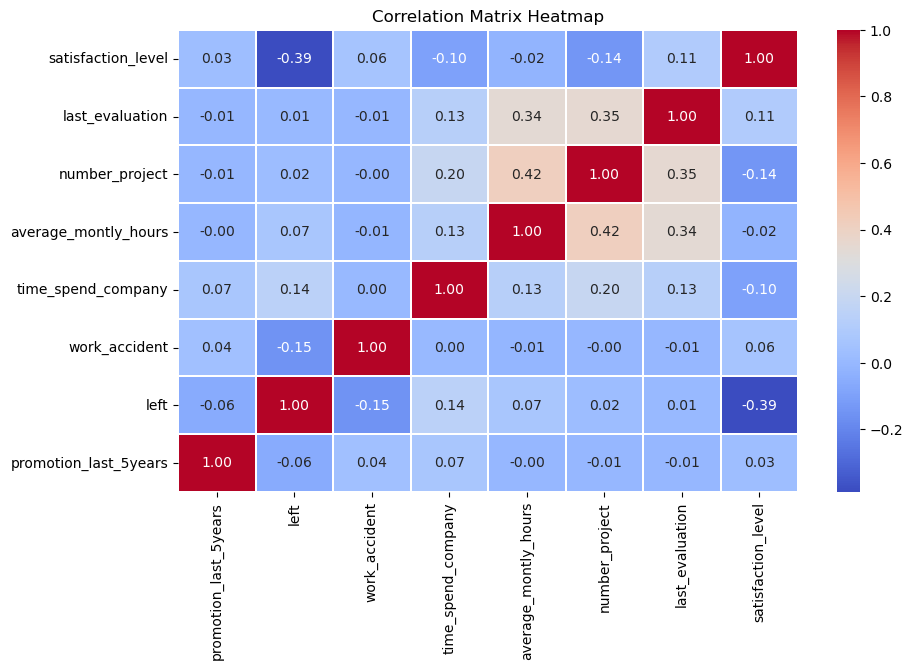

In [581]:
corr_matrix = df.select_dtypes(include = ['float','int']).corr() 

with sns.plotting_context(font_scale = 1.3): 
    plt.figure(figsize = (10, 6))
    sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.3).invert_xaxis()
    plt.title('Correlation Matrix Heatmap')
    plt.show()

Complete EDA of the Dataset

- From above findings it is clear that data has no null values 
- Correlation matrix shows that last evaluation column has very low correlation with the target. Hence, it may not be usefull for the model and we can drop it.
- Satisfaction level column has strong negative correlation with the target
- There is no much evidence for multicollinearity.

- DATA VISUALIZATION


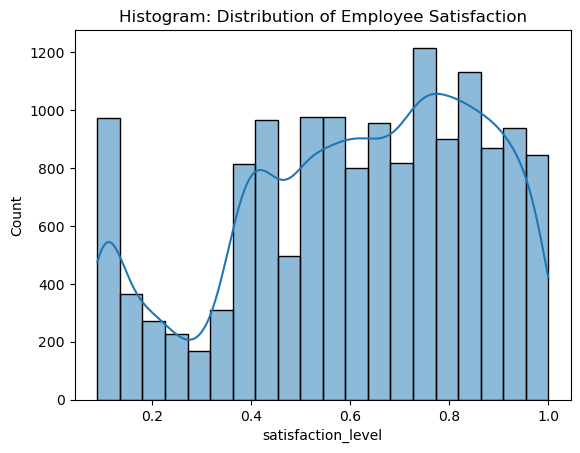

In [582]:
# Distribution plot of employee satisfaction
sns.histplot(df['satisfaction_level'], bins=20, kde=True)
plt.title('Histogram: Distribution of Employee Satisfaction')
plt.show()

In [583]:
df['satisfaction_level'].value_counts(ascending = False)

satisfaction_level
0.10    358
0.11    335
0.74    257
0.77    252
0.84    247
       ... 
0.25     34
0.28     31
0.27     30
0.12     30
0.26     30
Name: count, Length: 92, dtype: int64

In [584]:
#number of people with low and high satisfaction level
low = df[(df['satisfaction_level'] <= 0.3)].shape[0]
high = df[(df['satisfaction_level'] > 0.5)].shape[0]

print("Low satisfaction:", low)
print("High satisfaction:", high)

Low satisfaction: 1941
High satisfaction: 10187


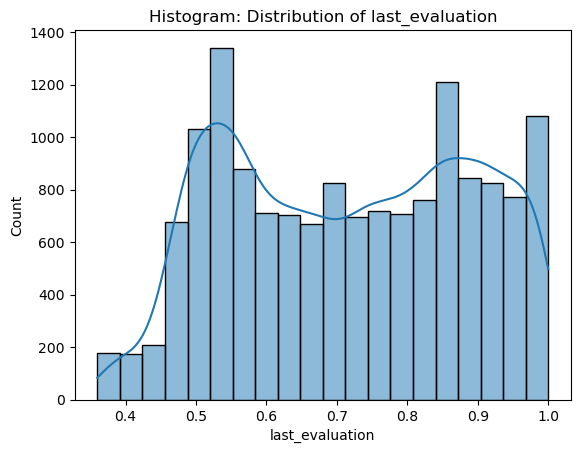

In [585]:
# Distribution plot of employee satisfaction
sns.histplot(df['last_evaluation'], bins=20, kde=True)
plt.title('Histogram: Distribution of last_evaluation')
plt.show()

In [586]:
df['last_evaluation'].value_counts(ascending = False)

last_evaluation
0.55    358
0.50    353
0.54    350
0.51    345
0.57    333
       ... 
0.39     52
0.43     50
0.38     50
0.44     44
0.36     22
Name: count, Length: 65, dtype: int64

In [587]:
# number of people with low and high evaluation ratings
low = df[(df['last_evaluation'] <= 0.45)].shape[0]
high = df[(df['last_evaluation'] > 0.7)].shape[0]

print("Low evaluation:", low)
print("High evaluation:", high)

Low evaluation: 560
High evaluation: 7802


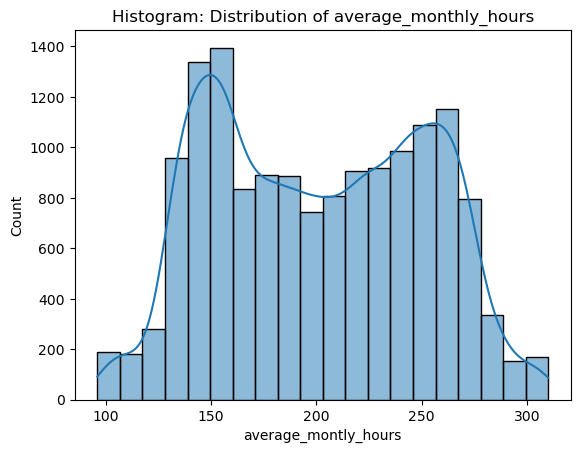

In [588]:
sns.histplot(df['average_montly_hours'], bins=20, kde=True)
plt.title('Histogram: Distribution of average_monthly_hours')
plt.show()

In [589]:
low = df[df['average_montly_hours'] <= 130].shape[0]

medium = df[(df['average_montly_hours'] > 130) & 
            (df['average_montly_hours'] <= 200)].shape[0]

very_high = df[df['average_montly_hours'] > 200].shape[0]

print("low_monthly_hours:", low)
print("medium_monthly_hours:", medium)
print("high_monthly_hours:", very_high)

low_monthly_hours: 770
medium_monthly_hours: 6754
high_monthly_hours: 7475


Data Visualization summary report. 

- From employee satisfaction distribution plot we find that data is not normally distributed and has clear difference in employees with low satisfaction and high satisfaction levels.
- There are some employees with less satisfaction but mainly employees with high satisfaction count is more
- From last evaluation distribution plot we find that data is not normally distributed and mainly less amount of people are evaluated with minimum ratings and good number of people are evaluated with maximum ratings.
- From average monthly hours plot we find that good number of people are working for greater than average 200 hours monthly and 770 number of people are working less hours

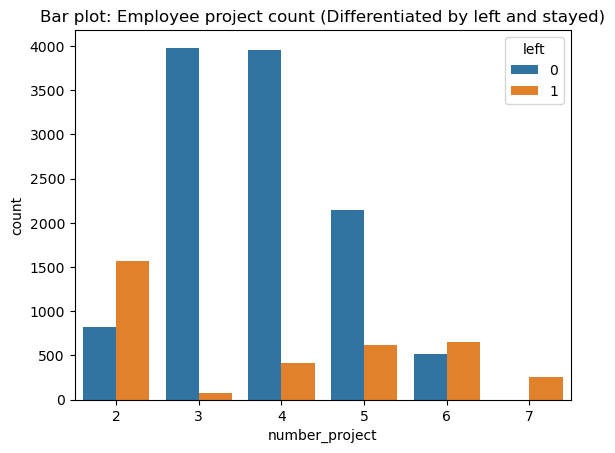

In [590]:
sns.countplot(x='number_project', data=df, hue='left')
plt.title('Bar plot: Employee project count (Differentiated by left and stayed)')
plt.show()

- From above analysis it is infered that most of the employees have done 3-4 projects and  stayed with the company and some of the employees have done only 2 projects and left the company.
- Some employees have done high number of projects and still left the company.

In [591]:
df.shape

(14999, 10)

In [592]:
left_emp = df[df['left'] == 1]

In [593]:
x = left_emp[['satisfaction_level', 'last_evaluation']]

In [594]:
kmeans = KMeans(n_clusters=3, random_state=42)
left_emp['cluster'] = kmeans.fit_predict(x)

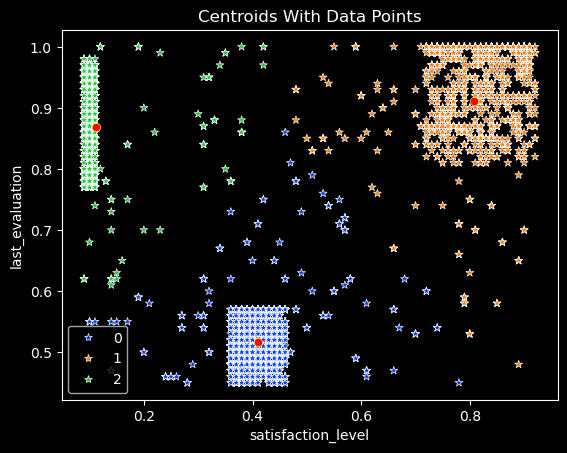

In [595]:
with plt.style.context('dark_background'): 
    sns.scatterplot(left_emp, x = 'satisfaction_level', y = 'last_evaluation', hue = 'cluster', palette = 'bright', marker = '*')
    sns.scatterplot(x = kmeans.cluster_centers_[:, 0], y = kmeans.cluster_centers_[:, 1], color = 'red', sizes = 150, edgecolor = 'yellow')
    plt.title(f'centroids with data points'.title())
    plt.show()

From above plot it is infered that there are 3 types of clusters 
- 1st red cluster which shows cluster of people who left they had high satisfaction level and high last evaluation rating.
- 0th  blue cluster which shows cluster of people who left with medium satisfaction level and poor last evaluation rating.
- 2th green cluster shows cluster of people who left with poor satisfaction level and high last evaluation rating.

Handling class imbalances using SMOTE technique

In [707]:
df.left.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

Data Preprocessing by converting categorical variables into numeric

In [708]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

- Converting Categorical columns into numeric using pd.get_dummies and concatenatng both converted categorical and numeric and upsampling using SMOTE technique

In [709]:
cat_cols = df[['department', 'salary']]
num_cols = df[['satisfaction_level', 'last_evaluation', 'number_project','average_montly_hours', 'time_spend_company', 'work_accident', 'left','promotion_last_5years']]

In [710]:
df_cat = pd.get_dummies(cat_cols, drop_first = True)

In [711]:
df_num = num_cols

In [712]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

In [713]:
print(pd.concat([df_cat, df_num], axis=1).columns)

Index(['department_RandD', 'department_accounting', 'department_hr',
       'department_management', 'department_marketing',
       'department_product_mng', 'department_sales', 'department_support',
       'department_technical', 'salary_low', 'salary_medium',
       'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years'],
      dtype='str')


In [735]:
x = pd.concat([df_cat, df_num],axis = 1).drop('left', axis = 1)
y = df['left']

In [736]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=123
)

In [737]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((11999, 18), (11999,), (3000, 18), (3000,))

In [738]:
x_resampled, y_resampled = SMOTE(sampling_strategy = 'minority').fit_resample(x_train, y_train)

In [739]:
x_resampled.shape, y_resampled.shape

((18284, 18), (18284,))

In [740]:
y_resampled.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

Training LogisticRegression Model 

In [742]:
log_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),    
    ('model', LogisticRegression(max_iter=2000)),
    
])

y_pred_cv = cross_val_predict(
    log_pipe,
    x_resampled,      
    y_resampled,     
    cv=5
)

log_pipe.fit(x_resampled, y_resampled)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [743]:

accuracy_score(y_resampled, y_pred_cv)

0.9507219426821264

In [744]:
log_pipe.classes_

array([0, 1])

In [745]:
log_pipe.predict_proba(x_resampled)[:5]

array([[8.96587121e-01, 1.03412879e-01],
       [3.20930450e-02, 9.67906955e-01],
       [9.13034278e-01, 8.69657221e-02],
       [9.98487235e-01, 1.51276545e-03],
       [9.99815985e-01, 1.84015407e-04]])

In [746]:
y_resampled[:5]

0    0
1    1
2    0
3    0
4    0
Name: left, dtype: int64

In [747]:
pred_df = pd.concat([pd.DataFrame(log_pipe.predict_proba(x_resampled))], 
          axis = 1, 
          ignore_index = True).rename(columns = {0: 'stayed', 1: 'left'})



pred_df['y_true'] = pd.DataFrame(y_resampled)
pred_df['y_pred'] = clf_log.predict(xtrain)
pred_df

,stayed,left,y_true,y_pred
0,0.896587,0.103413,0,1
1,0.032093,0.967907,1,1
2,0.913034,0.086966,0,1
3,0.998487,0.001513,0,0
4,0.999816,0.000184,0,1
...,...,...,...,...
18279,0.009455,0.990545,1,1
18280,0.000152,0.999848,1,1
18281,0.152965,0.847035,1,1
18282,0.081383,0.918617,1,1


From below confusion matrix it is inferrred that

Recall is the more important metric, because missing employees who are likely to leave (false negatives) is more costly than incorrectly predicting someone will leave (false positives).

A high Recall ensures that most employees at risk of leaving are identified, allowing the company to take preventive actions.

In [748]:
confusion_matrix(y_resampled, y_pred_cv)

array([[8658,  484],
       [ 417, 8725]])

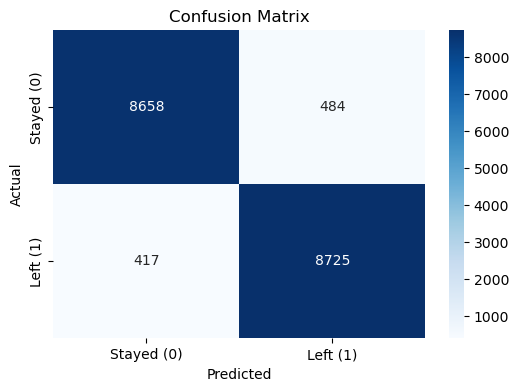

In [749]:
cm = confusion_matrix(y_resampled, y_pred_cv)
plt.figure(figsize = (6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Stayed (0)', 'Left (1)'], yticklabels = ['Stayed (0)', 'Left (1)'] )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [750]:
precision_score(y_resampled, y_pred_cv)

0.9474427190791617

In [751]:
recall_score(y_resampled, y_pred_cv)

0.9543863487201926

Below is the classification report of the model


In [627]:
print(classification_report(y_resampled, y_train_cv))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      9142
           1       0.96      0.96      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



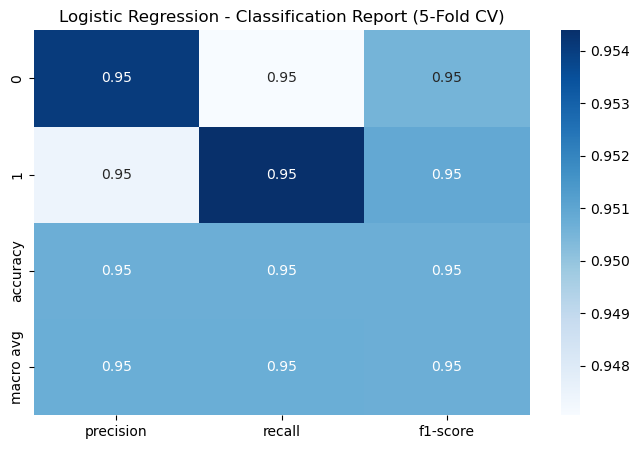

In [752]:
report = classification_report(y_resampled, y_pred_cv, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues')
plt.title("Logistic Regression - Classification Report (5-Fold CV)")
plt.show()

Below is the ROC Curve and ROC/AUC score of the model

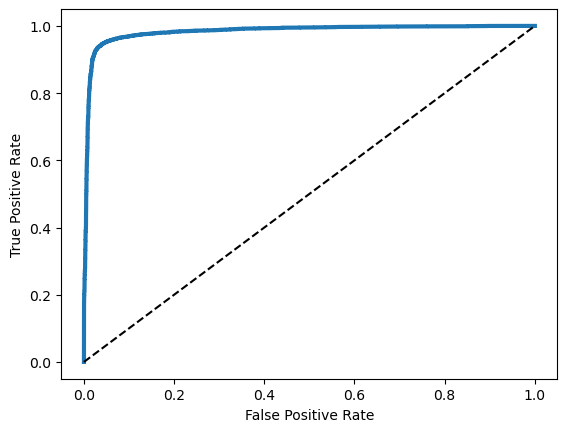

In [753]:
scores = cross_val_predict(log_pipe, x_resampled, y_resampled, cv = 5, method = 'decision_function', n_jobs = 1)

fpr, tpr, thresholds = roc_curve(y_resampled, scores)

def plot_roc_curve(fpr, tpr, label = None):
    plt.plot(fpr, tpr, linewidth = 3, label = label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

plot_roc_curve(fpr, tpr)

In [754]:
auc_log = roc_auc_score(y_resampled, scores)
auc_log

0.9833782751742471

In [755]:
threshold = 0.3

y_pred_new = (scores >= threshold).astype(int)

In [756]:
print(confusion_matrix(y_resampled, y_pred_new))

[[8749  393]
 [ 474 8668]]


Training a Random Forest Classifier

In [633]:
x = pd.concat([df_cat, df_num],axis = 1).drop('left', axis = 1)
y = df['left']

In [634]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=123
)

In [757]:
x_resampled.shape, y_resampled.shape

((18284, 18), (18284,))

In [758]:
clf_pipe = Pipeline([
    ('classifier', RandomForestClassifier(oob_score=True, n_jobs=3))
])

params = {
    'classifier__n_estimators': [50, 75, 100],
    'classifier__max_depth': [2, 3, 4, 5]
}

clf_grid = GridSearchCV(
    clf_pipe,
    param_grid=params,
    scoring='recall',   
    cv=5,
    n_jobs=3,
    verbose=2
)

clf_grid.fit(x_resampled, y_resampled)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=75; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=75; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=75; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=75; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=75; total time=   0.1s
[CV] END classifier__max_depth=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=2, cl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...score=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [50, 75, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [759]:
best_model = clf_grid.best_estimator_

y_pred = best_model.predict(x_resampled)


In [638]:
accuracy_score(y_resampled, y_pred)

0.950557864799825

In [760]:
y_train_cv = cross_val_predict(best_model, xtrain, y_resampled, cv = 5)

Recall is the more important metric, because misssing employees who are likely to leave(false negatives) is more costly than incorrectly predicting someone will leave (false positives)

From below confusion matrix it looks like false negatives are many than false positives which is a concern regarding our business problem which is to find employee turnover

A high recall ensures that most employees at risk of leaving are identified, allowing the company to take preventive actions.

In [761]:
confusion_matrix(y_resampled, y_train_cv)

array([[8902,  240],
       [ 723, 8419]])

In [762]:
clf_grid.best_params_

{'classifier__max_depth': 5, 'classifier__n_estimators': 50}

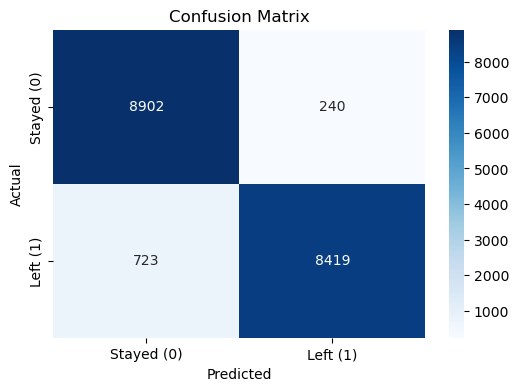

In [763]:
cm = confusion_matrix(y_resampled, y_train_cv)
plt.figure(figsize = (6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Stayed (0)', 'Left (1)'], yticklabels = ['Stayed (0)', 'Left (1)'] )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

From below classification report it seems like Recall for left(left = 1) is low when compare to precision. Our goal is to increase the recall to solve our business problem we can try decreasing threshold value so that most of the false negatives turn true positives.

In [764]:
print(classification_report(y_resampled, y_train_cv))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      9142
           1       0.97      0.92      0.95      9142

    accuracy                           0.95     18284
   macro avg       0.95      0.95      0.95     18284
weighted avg       0.95      0.95      0.95     18284



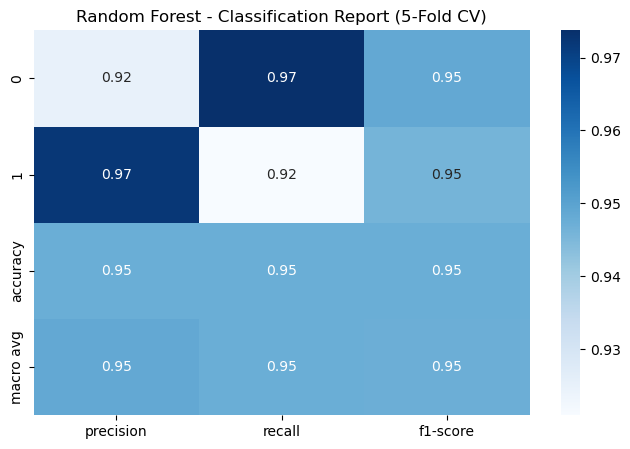

In [765]:
report = classification_report(y_resampled, y_train_cv, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues')
plt.title("Random Forest - Classification Report (5-Fold CV)")
plt.show()

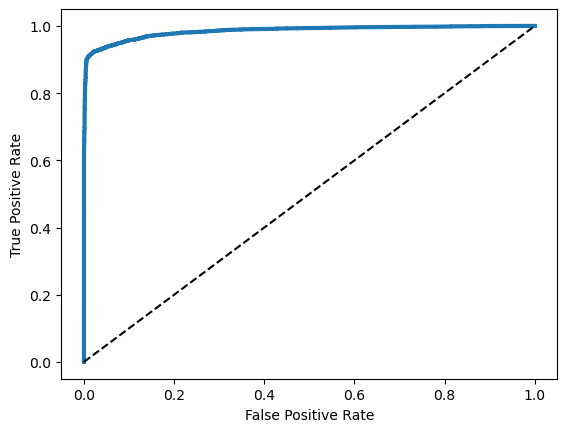

In [766]:
scores = cross_val_predict(best_model, xtrain, y_resampled, cv = 5, method = 'predict_proba', n_jobs = 1)[:,1]

fpr, tpr, thresholds = roc_curve(y_resampled, scores)

def plot_roc_curve(fpr, tpr, label = None):
    plt.plot(fpr, tpr, linewidth = 3, label = label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

plot_roc_curve(fpr, tpr)

In [767]:
auc_log = roc_auc_score(y_resampled, scores)
auc_log

0.9848118956500566

By setting the threshold we can see we have much reduced false negatives but false positives are very high.

In [768]:
threshold = 0.3

y_pred_new = (scores >= threshold).astype(int)

In [769]:
print(confusion_matrix(y_resampled, y_pred_new))


[[7725 1417]
 [ 260 8882]]


In [770]:
print(classification_report(y_resampled, y_pred_new))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      9142
           1       0.86      0.97      0.91      9142

    accuracy                           0.91     18284
   macro avg       0.91      0.91      0.91     18284
weighted avg       0.91      0.91      0.91     18284



Training a Gradient Boosting Classifier

In [771]:
x_resampled.shape, y_resampled.shape

((18284, 18), (18284,))

In [774]:
gb_model = GradientBoostingClassifier(random_state = 42)


In [775]:
y_train_cv = cross_val_predict(gb_model, x_resampled, y_resampled, cv=5)

In [776]:

accuracy_score(y_resampled, y_train_cv)

0.964996718442354

Below confusion matrix shows slightly high false negatives. Our goal is to trying to reduce false negatives to increase recall.

In [777]:
confusion_matrix(y_resampled, y_train_cv)

array([[8943,  199],
       [ 441, 8701]])

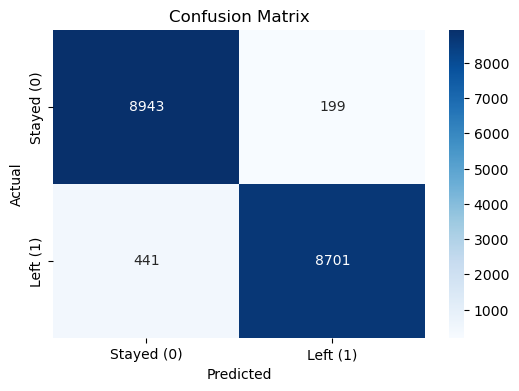

In [778]:
cm = confusion_matrix(y_resampled, y_train_cv)
plt.figure(figsize = (6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Stayed (0)', 'Left (1)'], yticklabels = ['Stayed (0)', 'Left (1)'] )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [779]:
print(classification_report(y_resampled, y_train_cv))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.97      0.96      0.96     18284
weighted avg       0.97      0.96      0.96     18284



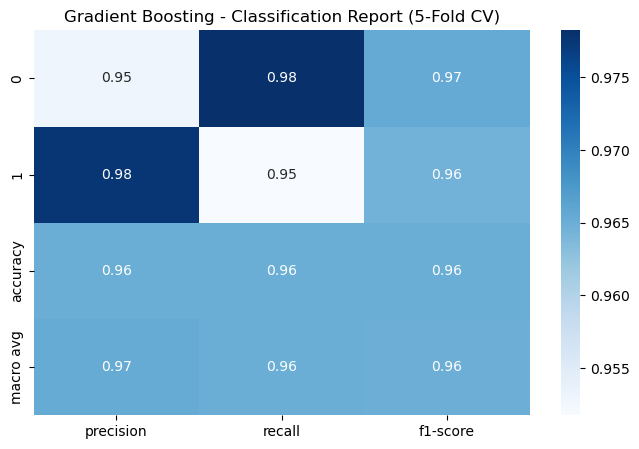

In [780]:
report = classification_report(y_resampled, y_train_cv, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues')
plt.title("Gradient Boosting - Classification Report (5-Fold CV)")
plt.show()

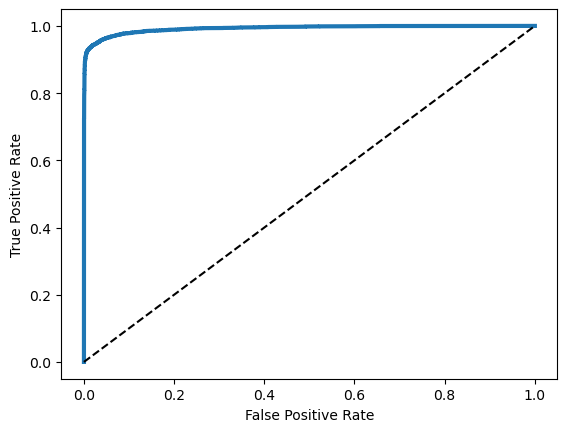

In [781]:
scores = cross_val_predict(gb_model, xtrain, y_resampled, cv = 5, method = 'predict_proba', n_jobs = 1)[:,1]

fpr, tpr, thresholds = roc_curve(y_resampled, scores)

def plot_roc_curve(fpr, tpr, label = None):
    plt.plot(fpr, tpr, linewidth = 3, label = label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

plot_roc_curve(fpr, tpr)

In [782]:
auc_log = roc_auc_score(y_resampled, scores)
auc_log

0.9923328558128129

Set the threshold value and false negatives are decreased by good number and roc/auc score is also high for GradientBoosting model when compared to other model.

In [783]:
threshold = 0.3

y_pred_new = (scores >= threshold).astype(int)

In [784]:
print(confusion_matrix(y_resampled, y_pred_new))


[[8604  538]
 [ 297 8845]]


By comparing all the three confusion matrix Gradient Boosting is the best model because it achieves low false negatives(302), which is critical for identifying employees likely to leave, while maintaining reasonable false positives(532).

Although Random Forest also has low false negatives, it produces significantly higher false positives, making it less efficient.

Logistic Regression has fewer false positives but higher false negatives, which is undesirable for employee turnover(churn) prediction.

Evaluation on Test data set using our best model GradientBoosting Classifier

In [785]:
x_test.shape, y_test.shape

((3000, 18), (3000,))

In [786]:
gb_model.fit(x_resampled, y_resampled)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [787]:
y_pred = gb_model.predict(x_test)

In [788]:
scores_test = gb_model.predict_proba(x_test)[:, 1]

In [794]:
df_results = pd.DataFrame({'Probability' : scores_test})

def categorize_zone(p):
    if p < 0.2:
        return 'Safe (Green)'

    elif p < 0.6:
        return 'Low Risk (Yellow)'

    elif p < 0.9:
        return 'Medium Risk (Orange)'

    else:
        return 'High Risk (Red)'

df_results['zone'] = df_results['Probability'].apply(categorize_zone)
df_results.head()

,Probability,zone
0,0.005764,Safe (Green)
1,0.944124,High Risk (Red)
2,0.080032,Safe (Green)
3,0.016039,Safe (Green)
4,0.027151,Safe (Green)


In [ ]:
df_results['zone'].value_counts()


zone
Safe (Green)            2110
High Risk (Red)          612
Low Risk (Yellow)        193
Medium Risk (Orange)      85
Name: count, dtype: int64

Retention Strategies For Each Zone

1. Safe zone - Many numbers fall in safe zone and very unlikely to leave. Strategies like maintaining engagement, conducting recognition programs and career growth discusssions can help.

2. High Risk zone - Likely to leave. Firstly, have to find out what is the root cause for leaving(workload, manager, culture). Company can provide retention bonus, promotion or role change.

3. Low Risk zone - There is a slight risk here. Company can apply strategies like regular check-ins, improve work-life balance, small incentives could work.

4. Medium Risk zone - This is a AT risk zone. Can apply strategies like manager intervention, salary benchmarking, role alignment.
